In [1]:
import numpy as np
import matplotlib.pyplot as plt

proton_mass = 1.67e-27 # mass of a proton in kg
proton_charge = 1.6e-19 # charge of a proton in coulombs

spectrometer_params = {
    's': 0.1, # height of the velocity selector in meters
    'p1': 0.2, # height of the magnetic field region in meters
    'p2': 0.3, # height of the chamber in meters
    'd': 0.1, # horizontal position of the detector in meters
    'dt': 1e-7 # time step in seconds
}

### The Boris algorithm

Before defining the simulation function, I would like to briefly comment on the numerical integration scheme used to calculate the particle trajectories.

Initially, I considered using the **Verlet** integration as usual, which is a standard choice in many physics simulations (like molecular dynamics). However, Verlet is designed for forces that depend strictly on *position* ($\vec{F}(\vec{x})$), like gravity or springs. The Lorentz force ($\vec{F} = q(\vec{E} + \vec{v} \times \vec{B})$) introduces a complication because the magnetic component depends directly on the particle's *velocity*. Attempting to use Verlet with a velocity-dependent force creates an implicit equation (you need the future velocity to calculate the future velocity), which makes the algorithm computationally messy and breaks its natural simplicity.

Instead, I chose to implement the **Boris algorithm**, which is the *de facto* standard for tracing charged particles in electromagnetic fields (especially in plasma physics). The Boris method elegantly handles the velocity dependence by splitting the force update into three distinct steps:
1. A half-step acceleration caused only by the electric field.
2. A pure rotation of the velocity vector caused by the magnetic field (which realistically does no work and changes no energy).
3. A final half-step acceleration from the electric field.

My choice is strongly supported by computational physics literature. In the paper *"Why is Boris Algorithm So Good?"* (Qin et al., 2013, [OSTI: 1090047](https://www.osti.gov/servlets/purl/1090047)), the authors compare the Boris algorithm to standard explicit solvers like the 4th-Order Runge-Kutta (RK4). Standard ODE solvers like RK4 are not volume-preserving, meaning that over long timescales, numerical errors accumulate and the system's energy artificially drifts. Qin et al. prove that the Boris algorithm perfectly conserves phase space volume. This unique property provides a global bound on energy errors, ensuring that the simulated particle's energy remains stable over millions of iterations. For our mass spectrometer, where long-term trajectory accuracy is the entire goal, the Boris algorithm is superior.

The specific vector algebra implementation used in this simulation utilizing the intermediate tangent ($\vec{t}$) and scaling ($\vec{s}$) vectors to perform the $\vec{v} \times \vec{B}$ rotation without changing the velocity magnitude was adapted from the standard formulation detailed by Lubos Brieda (2011, *Particle In Cell Consulting*, [Particle Push in Magnetic Field (Borid Method)](https://www.particleincell.com/2011/vxb-rotation/)).

In [2]:
def simulate_particle(m, q, spectrometer_params, v_s, Bz, Ex=None, verbose=False):
    dt = spectrometer_params.get('dt', 1e-7)
    initial_position = np.array([0, 0, 0]) # initial position of the particle (x, y, z)

    if Ex is None:
        Ex = -v_s * Bz
        
    E = np.array([Ex, 0, 0]) # electric field vector (Ex, Ey, Ez)
    B = np.array([0, 0, Bz]) # magnetic field vector (Bx, By, Bz)

    initial_velocity = np.array([0, v_s, 0]) # initial velocity of the particle (vx, vy, vz)

    positions = [initial_position]
    velocities = [initial_velocity]

    while positions[-1][0] <= spectrometer_params['d'] and positions[-1][1] <= spectrometer_params['p2']:
        if positions[-1][1] >= spectrometer_params['s']:
            E = np.array([0, 0, 0]) # electric field is turned off after the particle reaches height s
        if positions[-1][1] >= spectrometer_params['p1']:
            B = np.array([0, 0, 0]) # magnetic field is turned off after the particle reaches height p1

        t_vec = q/m * B * dt / 2
        s_vec = 2 * t_vec / (1 + np.dot(t_vec, t_vec))

        half_E_step = q/m * E * dt / 2

        half_E_push = velocities[-1] + half_E_step
        cross1 = half_E_push + np.cross(half_E_push, t_vec)
        
        cross2 = half_E_push + np.cross(cross1, s_vec)
        new_velocity = cross2 + half_E_step
        new_position = positions[-1] + new_velocity*dt

        if new_velocity[1] < 0:
            if verbose:
                print("The proton has turned back, which should not happen in a velocity selector. Check the parameters.")
            break

        positions.append(new_position)
        velocities.append(new_velocity)

    return positions, velocities



### Note on data storage and optimization

In the simulation function, the particle trajectories (positions and velocities) are stored by dynamically appending to standard Python lists at each time step, rather than using pre-allocated NumPy arrays. 

From a strict computational optimization standpoint, pre-allocating a large, fixed-size `numpy.ndarray` of zeros and updating it via an index counter would be significantly faster and more memory-efficient. Python's `.append()` method requires frequent memory reallocation under the hood, which introduces computational overhead especially when running thousands of iterations in a `while` loop. 

However, in this implementation I decided to prioritize code readability and structural clarity over maximum execution speed. The list appending method keeps the simulation loop intuitive and easy to follow without getting burried in array indexing and slicing logic. Given the relatively short flight path of the particles in my setup, the performance cost is negligible, making the trade-off for cleaner, more transparent code the better choice here.

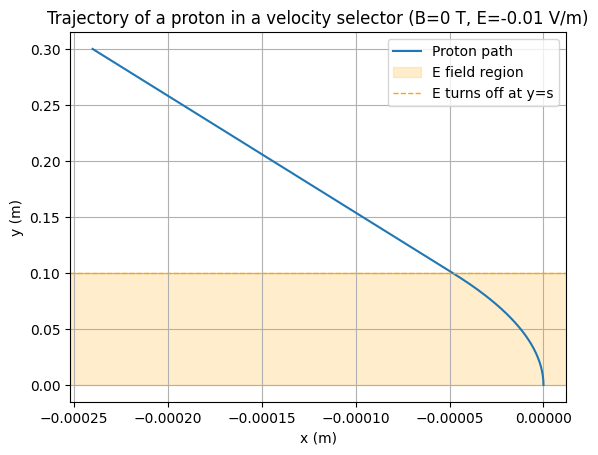

In [3]:
v_s = 1e4 # speed of the proton in m/s
Bz = 0 # magnetic field strength in tesla
Ex = -0.01 # electric field strength in V/m

positions, velocities = simulate_particle(proton_mass, proton_charge, spectrometer_params, v_s, Bz, Ex=Ex, verbose=True)

x_positions = [pos[0] for pos in positions]
y_positions = [pos[1] for pos in positions]

plt.plot(x_positions, y_positions, label='Proton path')
plt.axhspan(0, spectrometer_params['s'], color='orange', alpha=0.2, label='E field region')
plt.axhline(spectrometer_params['s'], color='orange', linestyle='--', linewidth=1, label='E turns off at y=s')
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.title(f'Trajectory of a proton in a velocity selector (B=0 T, E={Ex} V/m)')
plt.legend(loc='best')
plt.grid()
plt.show()

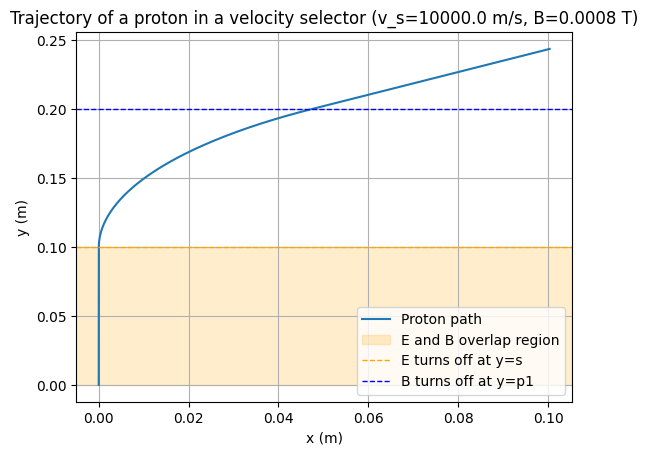

In [4]:
v_s = 1e4
Bz = 0.0008

positions, velocities = simulate_particle(proton_mass, proton_charge, spectrometer_params, v_s, Bz)

x_positions = [pos[0] for pos in positions]
y_positions = [pos[1] for pos in positions]

plt.plot(x_positions, y_positions, label='Proton path')
plt.axhspan(0, spectrometer_params['s'], color='orange', alpha=0.2, label='E and B overlap region')
plt.axhline(spectrometer_params['s'], color='orange', linestyle='--', linewidth=1, label='E turns off at y=s')
plt.axhline(spectrometer_params['p1'], color='blue', linestyle='--', linewidth=1, label='B turns off at y=p1')
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.title(f'Trajectory of a proton in a velocity selector (v_s={v_s} m/s, B={Bz} T)')
plt.legend(loc='best')
plt.grid()
plt.show()

Spectrometer parameters: s=0.1 m, p1=0.2 m, p2=0.3 m, d=0.1 m

Velocity selector parameters: v_s=10000.0 m/s, Bz=0.0008 T
Minimal m/q ratio: 8.07730855855856e-09, Maximal m/q ratio: 1.4179954954954957e-08


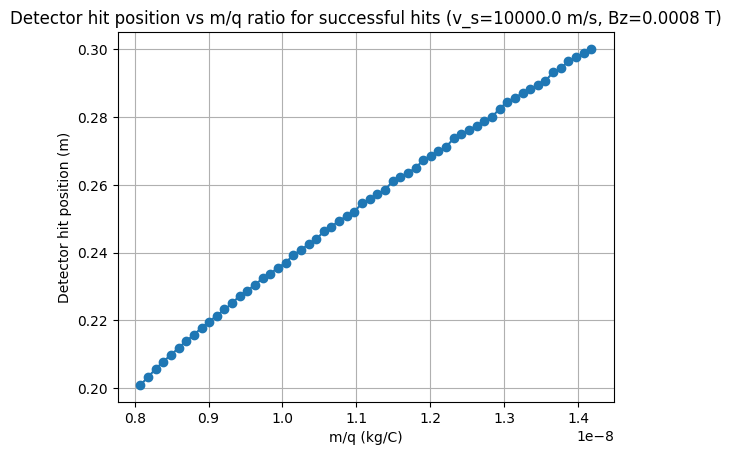


Velocity selector parameters: v_s=20000.0 m/s, Bz=0.001 T
Minimal m/q ratio: 4.9742680180180185e-09, Maximal m/q ratio: 8.904786036036036e-09


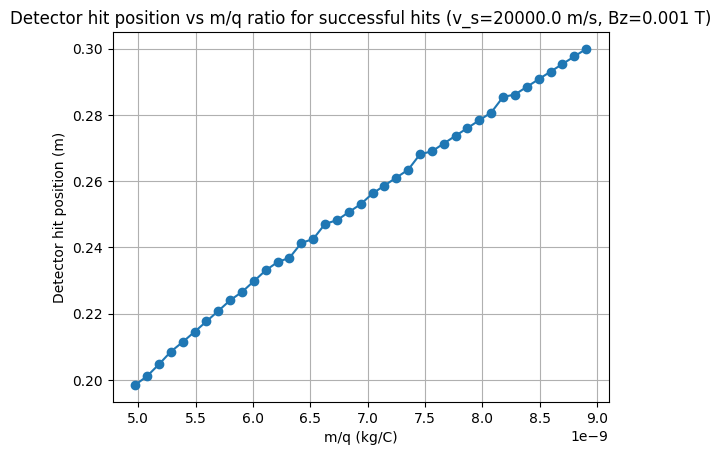

In [5]:
def run_experiment(q, spectrometer_params, experimental_masses, v_s, Bz):
    successful_mq_ratios = []
    detector_hit_positions = []

    for test_m in experimental_masses:
        positions, velocities = simulate_particle(test_m, q, spectrometer_params, v_s, Bz)

        if positions[-1][0] >= spectrometer_params['d']:
            successful_mq_ratios.append(test_m/proton_charge)
            detector_hit_positions.append(positions[-1][1]) # record the y position where the particle hits the detector

    print(f'\nVelocity selector parameters: v_s={v_s} m/s, Bz={Bz} T')

    if len(successful_mq_ratios) > 0:
        print(f'Minimal m/q ratio: {successful_mq_ratios[0]}, Maximal m/q ratio: {successful_mq_ratios[-1]}')

        plt.plot(successful_mq_ratios, detector_hit_positions, marker='o')
        plt.xlabel('m/q (kg/C)')
        plt.ylabel('Detector hit position (m)')
        plt.title(f'Detector hit position vs m/q ratio for successful hits (v_s={v_s} m/s, Bz={Bz} T)')
        plt.grid()
        plt.show()
    else:
        print("No particles with the tested m/q ratios reached the detector.")

print(f'Spectrometer parameters: s={spectrometer_params["s"]} m, p1={spectrometer_params["p1"]} m, p2={spectrometer_params["p2"]} m, d={spectrometer_params["d"]} m')

experimental_masses = np.linspace(proton_mass/10, 10*proton_mass, 1000) # hypothetical experimental mass values for testing various m/q ratios

run_experiment(proton_charge, spectrometer_params, experimental_masses, v_s=1e4, Bz=0.0008)
run_experiment(proton_charge, spectrometer_params, experimental_masses, v_s=2e4, Bz=0.001)

### Discussion on spectrometer resolution

Based on the characteristic curves generated during the two experimental runs, we can determine the resolution of the spectrometer. In this setup, resolution refers to how far apart two particles with very similar mass-to-charge ($m/q$) ratios will hit the detector. On our graphs, this is represented by the slope of the curve ($\Delta y / \Delta(m/q)$).

Looking at both plots, the curve is noticeably steeper at the lower end of the $m/q$ range and starts to flatten out as the mass increases. This indicates that **the spectrometer has better resolution for lighter particles**. 

The physics behind this makes sense when considering the cyclotron radius, $R = \frac{mv}{qB}$:
* **Lighter particles (lower $m/q$):** These particles have a smaller turning radius. The magnetic field bends them significantly, so even a tiny change in mass drastically alters their exit angle from the B-field region. This spreads their hit positions out widely across the detector, making them easy to tell apart (high resolution).
* **Heavier particles (higher $m/q$):** These particles have a much larger turning radius. They barely bend in the magnetic field and travel in a mostly straight, vertical path. Because the magnetic field struggles to steer them, adding a small amount of extra mass doesn't change their trajectory much. They end up bunching closely together near the top of the detector screen, making it harder to distinguish between them (low resolution).

**Future improvements:**
To improve the resolution for heavier particles in a future iteration of this device, the spectrometer must be modified to either decrease the cyclotron radius of massive ions or provide more physical space for their trajectories to diverge. This could be achieved physically in three ways:
1. **Increasing the magnetic field ($B_z$):** A stronger magnetic field would exert a greater Lorentz force, forcing heavier, "stiffer" trajectories to curve more sharply and spread out along the $y$-axis.
2. **Decreasing the injection velocity ($v_s$):** By tuning the velocity selector to admit slower particles, the ions would spend more time in the magnetic field region, resulting in a smaller curve radius. 
3. **Enlarging the chamber geometry:** Increasing the horizontal flight path to the detector ($d$) would give the slightly differing exit angles more horizontal distance to physically separate before striking the screen.